In [18]:
import langgraph
from langgraph.graph  import START,END,StateGraph
from typing import TypedDict


In [19]:
class batsmanstate(TypedDict):
    runs:int
    balls:int
    fours:int
    sixex:int

    sr:float
    bpb:float
    boundary_persentage:float
    summary:str
    

In [29]:
graph=StateGraph(batsmanstate)
from langgraph.graph import StateGraph, START, END

# Re-instantiate the graph object first
graph = StateGraph(batsmanstate)

# Now add nodes


In [62]:
def calculate_sr(state:batsmanstate)->batsmanstate:
    sr=(state['runs']/state['balls'])*100
    state['sr']=sr
    return {'sr':sr}

def calculate_bpb(state:batsmanstate)->batsmanstate:
    bpb=state['balls']/(state['fours'] +state['sixex'])
    state['bpb']=bpb
    return {'bpb':bpb}

def calculate_boundary_persentage(state: batsmanstate) -> batsmanstate:
    boundary_persentage = (((state['fours'] * 4) + (state['sixex'] * 6)) / state['runs']) * 100
    
    # --- Add this line to save it to the state ---
    state['boundary_persentage'] = boundary_persentage 
    
    return state 
def  summary(state:batsmanstate)-> batsmanstate:
    summary=f"""
struke rate -{state['sr']}\n
balls per boumdary - {state['bpb']}\n
boundary_persentage - {state['boundary_persentage'] } 
"""

    state['summary']=summary
    return {'summary':summary}
    
    

In [65]:
# add nodes
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_persentage', calculate_boundary_persentage)
graph.add_node('summary', summary)

# add egeeg
graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate__boundary_persentage')

graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('calculate_boundary_persentage','summary')

graph.add_edge('summary',END)
workflow=graph.compile()

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Node `calculate_sr` already present.

In [66]:
# 1. Re-initialize the graph object first!
graph = StateGraph(batsmanstate)

# 2. Add nodes
graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_persentage', calculate_boundary_persentage)
graph.add_node('summary', summary)

# 3. Add edges (Note the typo fix on line 12 below!)
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_persentage')  # Fixed double underscore typo here

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_persentage', 'summary')
graph.add_edge('summary', END)

# 4. Compile workflow
workflow = graph.compile()

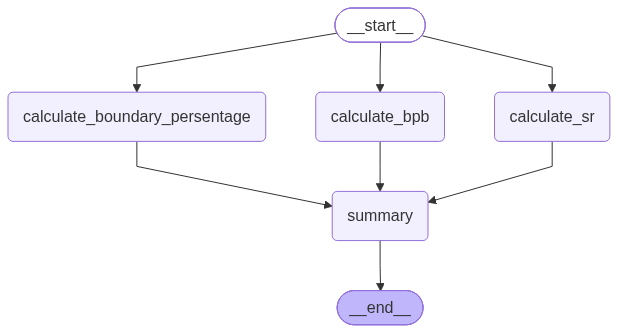

In [67]:
workflow

In [68]:
inatial_state={
    'runs':100,
    'balls':30,
    'fours':7,
    'sixex':8
}

In [69]:
res=workflow.invoke(inatial_state)
res

{'runs': 100,
 'balls': 30,
 'fours': 7,
 'sixex': 8,
 'sr': 333.33333333333337,
 'bpb': 2.0,
 'boundary_persentage': 76.0,
 'summary': '\nstruke rate -333.33333333333337\n\nballs per boumdary - 2.0\n\nboundary_persentage - 76.0 \n'}